In [3]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np

### A Chain with 6 states: 1,...,6. State 6 is terminal.
### First we examine a policy that oscilates between states 3 and 4
### 1. Stationary Distribution:

<BarContainer object of 6 artists>

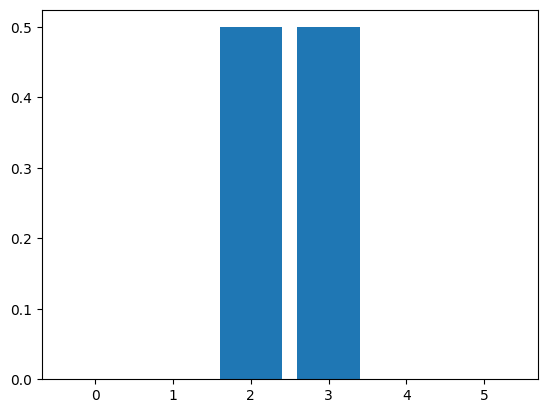

In [8]:
# Find the stationary distribution assuming resets
N = 6
P_dist = np.zeros((N, 2,N))

for s in range(N):
    if s == 5: # reset
        P_dist[s, :, 0] = 1.0 # back to start
    else:
        # Left
        P_dist[s, 0, max(0, s - 1)] = 1.0
        # Right
        P_dist[s, 1, s + 1] = 1.0
        
pi = np.zeros((N,2))
eps = 0.001
pi[0] = [0,1]    
pi[1] = [0,1]    
pi[2] = [eps,1-eps]    
pi[3] = [1-eps,eps]    
pi[4] = 0.5    
pi[5] = 0.5    
pi

P_dist = jnp.array(P_dist)
pi = jnp.array(pi)
P_pi_dist = jnp.einsum('sam,sa->sm', P_dist, pi)

# Stationary Dist:
# mu^T P = mu^T
# mu^T (I-P) = 0
# (I-P)^T mu = 0
# also constraint that mu is a distribution.

def compute_stationary(matrix):
    A = jnp.transpose(matrix) - jnp.eye(N)
    A = A.at[-1, :].set(jnp.ones(N))
    b = jnp.zeros(N).at[-1].set(1.0)
    return jnp.linalg.solve(A, b)

mu = compute_stationary(P_pi_dist)
plt.bar(jnp.arange(len(mu)), mu)

### 2. Intrinsic Reward

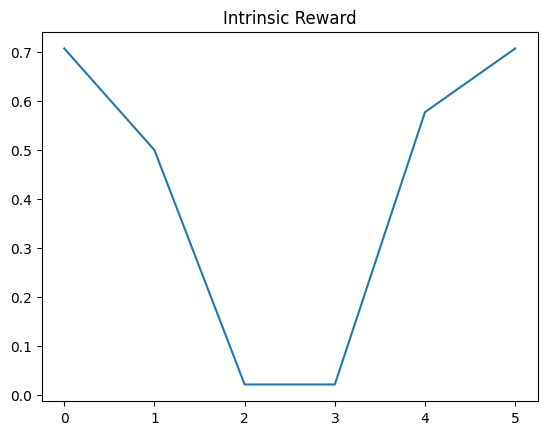

In [10]:
T = 128 * 32
visits = jnp.int32(jnp.round(mu * T))
visits

## Intrinsic Reward
Phi = jnp.eye(6)
T = jnp.sum(visits)
vist_mat = jnp.diag(visits)

indices = jnp.repeat(jnp.arange(len(visits)), visits)

data = Phi[indices]

gram = jnp.sum(jax.vmap(jnp.outer)(data, data), axis=0)
gram = 1/2 * gram +  1/2 * gram.T

ε = 0.0001
precision = jnp.linalg.inv(gram + jnp.eye(gram.shape[0]) + ε) 
r = []
for i in range(N): # for each state:
    M = Phi[i].T @ precision @ Phi[i]
    r.append(jnp.sqrt(M))
r = jnp.array(r)
plt.plot(r)
plt.title('Intrinsic Reward')
plt.show()


### 2. Value Function:

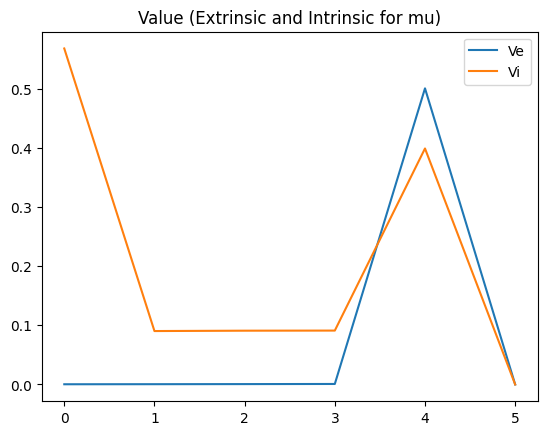

In [12]:
# Update for solving MDP
P = np.zeros((6, 2,6))
R = np.zeros(6)
gamma = 0.75

for s in range(6):
    if s == 5: # reset
        P[s, :, :] = 0.0 # terminates
        R[s] = 1.0
    else:
        # Left
        P[s, 0, max(0, s - 1)] = 1.0
        # Right
        P[s, 1, s + 1] = 1.0
P[:,1,:]
P_pi = jnp.einsum('sam,sa->sm', P, pi)
P_pi
A = jnp.eye(6)-gamma * P_pi
Ve = jnp.linalg.solve(A, P_pi @R)
Vi = jnp.linalg.solve(A, P_pi @r)
plt.plot(Ve, label = 'Ve')
plt.plot(Vi, label = 'Vi')
plt.legend()
plt.title('Value (Extrinsic and Intrinsic for mu)')
plt.show()



### LSTD

Text(0.5, 1.0, 'True LSTD Solution and Intrinsic Value')

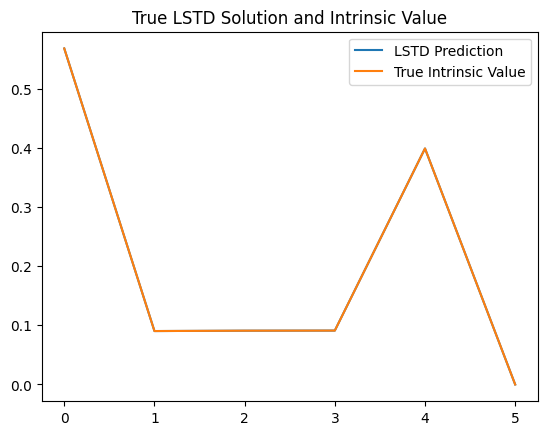

In [13]:
def solve_lstd_intrinsic(Phi, P_pi, mu, r, gamma=0.75):
    # D is the weighting of each state based on the stationary distribution
    D = jnp.diag(mu)
    
    # The A matrix in LSTD: E[phi_t (phi_t - gamma * phi_{t+1})^T]
    # In matrix form: Phi^T * D * (Phi - gamma * P_pi @ Phi)
    A_lstd = Phi.T @ D @ (Phi - gamma * P_pi @ Phi)
    
    # The b vector in LSTD: E[phi_t * r_t]
    # In matrix form: Phi^T * D * r
    # b_lstd = Phi.T @ D @ r
    b_lstd = Phi.T @ D @ P_pi @ r
    
    # Solve for the weights theta
    theta = jnp.linalg.solve(A_lstd, b_lstd)
    return theta

# For your case where Phi = jnp.eye(6):
V_lstd = solve_lstd_intrinsic(jnp.eye(6), P_pi, mu, r, gamma)

plt.plot(V_lstd, label = 'LSTD Prediction')
plt.plot(Vi, label = 'True Intrinsic Value')
plt.legend()
plt.title('True LSTD Solution and Intrinsic Value')

In [14]:
import distrax
rng = jax.random.PRNGKey(0)
def sample_policy(pi, s, rng):
    dist = distrax.Categorical(probs = pi[jnp.argmax(s,-1)])
    return dist.sample(seed=rng)
sample_policy(pi, Phi[1], rng)

Array(1, dtype=int32)

In [15]:
import sys
from pathlib import Path

# notebooks → deep
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
from envs.long_chain import LongChain
env = LongChain(6)
env_params = env.default_params

rng = jax.random.PRNGKey(0)

reset_rng = jax.random.split(rng, 128)

PROJECT_ROOT: /Users/dillonsandhu/Documents/Research/bayesian-rl/deep


In [16]:
pi[jnp.argmax(obsv,1)].shape

NameError: name 'obsv' is not defined

In [17]:
from typing import NamedTuple
class Transition(NamedTuple):
    done: jnp.ndarray
    action: jnp.ndarray
    reward: jnp.ndarray
    intrinsic_reward: jnp.ndarray 
    obs: jnp.ndarray
    next_obs: jnp.ndarray

def cross_cov(traces, current_features, next_features, done, γ):
    "One a sample of the LSTD A matrix - episodic"
    td_features = current_features - γ  * next_features * (1-done)
    A_sample = jnp.outer(traces, td_features)
    return A_sample

cross_cov_fix_gamma = lambda z, phi, phi_prime, done: cross_cov(z, phi, phi_prime, done, gamma)

def lstd(transitions, N):
        batch_axes = tuple(range(transitions.done.ndim))
        
        N = N + transitions.done.size
        # rho_scale = 1.0 / jnp.sqrt(N) # scale of intrinsic reward
        # rho = transitions.intrinsic_reward / rho_scale
        rho = transitions.intrinsic_reward 
        
        A_update = jax.vmap(jax.vmap(cross_cov_fix_gamma))(transitions.obs, transitions.obs, transitions.next_obs, transitions.done)
        A_batch = A_update.mean(axis=batch_axes)
        b_int_sample = transitions.obs * rho[..., None]
        b_i_batch = b_int_sample.mean(axis=batch_axes)
        εI = 1e-5 * jnp.eye(A_batch.shape[0])
        
        w_i = jnp.linalg.solve(A_batch + εI, b_i_batch)

        return w_i


def data_batch_lstd(rng, env_params, num_envs, num_steps, N):
    rng, _rng = jax.random.split(rng)
    reset_rng = jax.random.split(_rng, num_envs)
    obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)
    
    def collect_batch(rng):
        def _env_step(env_scan_state, unused):
            env_state, last_obs, rng = env_scan_state

            # Get Policy Action
            rng, _rng = jax.random.split(rng)
            action = sample_policy(pi, last_obs, _rng)

            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, num_envs)
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            ri = r[jnp.argmax(obsv, -1)]
            transition = Transition(done, action, reward,ri , last_obs, obsv)
            runner_state = (env_state, obsv, rng)
            return runner_state, transition
        # end _env_step

        env_step_state = (env_state, obsv, rng)
        (final_env_state, last_obs, rng), traj_batch = jax.lax.scan(
            _env_step, env_step_state ,None, num_steps
        )
        return traj_batch
    
    traj_batch = collect_batch(rng)
    wi = lstd(traj_batch, N)
    return wi


num_runs = 32
num_envs = 32
num_steps = 32
rng = jax.random.PRNGKey(0)
_rng = jax.random.split(rng, num_runs)


num_envs_int = int(num_envs)
num_steps_int = int(num_steps)
T_int = int(T)

jit_data_batch = jax.jit(data_batch_lstd, static_argnums=(2, 3, 4))

final_wi = jax.vmap(
    jit_data_batch, 
    in_axes=(0, None, None, None, None)
)(_rng, env_params, num_envs_int, num_steps_int, T_int)


/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


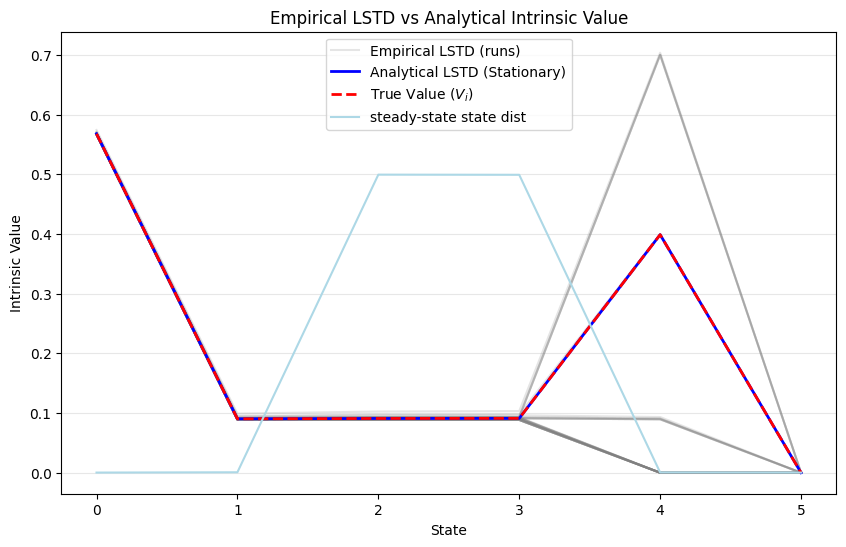

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot all 32 runs of final_wi with low opacity
# We transpose so final_wi.T is (States, Runs)
# Then we iterate over columns (each run)
for i in range(num_runs):
    # Set label only for the first one to avoid legend duplicates
    label = 'Empirical LSTD (runs)' if i == 0 else ""
    plt.plot(final_wi[i], color='gray', alpha=0.2, label=label)

# Plot the analytical solutions for comparison
plt.plot(V_lstd, color='blue', linewidth=2, label='Analytical LSTD (Stationary)')
plt.plot(Vi, color='red', linewidth=2, linestyle='--', label='True Value ($V_i$)')
plt.plot(mu, color='lightblue', label = 'steady-state state dist')

plt.legend()
plt.xlabel('State')
plt.ylabel('Intrinsic Value')
plt.title('Empirical LSTD vs Analytical Intrinsic Value')
plt.grid(axis='y', alpha=0.3)
plt.show()

$$
G = \sum_s N(s) \phi(s) \phi(s)^\top$$
$$
x^\top G^{-1} x \leq \frac{1}{\sum_s N(s) x^\top \phi(s)}
$$

In [ ]:
# version that *computes* intrinsic reward based on visit count...

def get_int_rew(S, features, N):
    Sigma_inv = jnp.linalg.solve(S + config['GRAM_REG'] * jnp.eye(features.shape[-1]), jnp.eye(features.shape[-1]))
    bonus_sq = jnp.einsum('...i,ij,...j->...', features, Sigma_inv, features)
    bonus_sq /= jnp.maximum(1.0, N)
    rho = beta_fn(N) * jnp.sqrt(bonus_sq)
    return rho

def data_batch_lstd(rng, env_params, num_envs, num_steps, N):
    rng, _rng = jax.random.split(rng)
    reset_rng = jax.random.split(_rng, num_envs)
    obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)
    
    def collect_batch(rng):
        def _env_step(env_scan_state, unused):
            env_state, last_obs, rng = env_scan_state

            # Get Policy Action
            rng, _rng = jax.random.split(rng)
            action = sample_policy(pi, last_obs, _rng)

            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, num_envs)
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            ri = r[jnp.argmax(obsv, -1)]
            transition = Transition(done, action, reward,ri , last_obs, obsv)
            runner_state = (env_state, obsv, rng)
            return runner_state, transition
        # end _env_step

        env_step_state = (env_state, obsv, rng)
        (final_env_state, last_obs, rng), traj_batch = jax.lax.scan(
            _env_step, env_step_state ,None, num_steps
        )
        return traj_batch
    
    traj_batch = collect_batch(rng)
    wi = lstd(traj_batch, N)
    return wi


num_runs = 32
num_envs = 128
num_steps = 128
rng = jax.random.PRNGKey(0)
_rng = jax.random.split(rng, num_runs)


num_envs_int = int(num_envs)
num_steps_int = int(num_steps)
T_int = int(T)

jit_data_batch = jax.jit(data_batch_lstd, static_argnums=(2, 3, 4))

final_wi = jax.vmap(
    jit_data_batch, 
    in_axes=(0, None, None, None, None)
)(_rng, env_params, num_envs_int, num_steps_int, T_int)


Array(100, dtype=int32)

In [127]:
for i in range(N):
    N_eff = 1/(r[i]**2) # ri = sqrt(1/n) -> n = 1/ri^2
    print('n_eff', N_eff)
    alpha = jnp.clip(N_eff / 20, 0.0, 1.0) # neff = 10 -> r = 1/sqrt(10)
    print('alpha = ', alpha)

n_eff 84.538185
alpha =  1.0
n_eff 10.97344
alpha =  0.548672
n_eff 20.973406
alpha =  1.0
n_eff 1.649811
alpha =  0.08249055
